In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import random, warnings, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from datetime import timedelta
from IPython.display import display
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import scipy.stats as st

# HD95 — only used at TEST TIME, not during val epochs
try:
    from medpy.metric.binary import hd95 as _hd95
    HD95_OK = True
except ImportError:
    os.system("pip install medpy -q")
    try:
        from medpy.metric.binary import hd95 as _hd95
        HD95_OK = True
    except:
        HD95_OK = False

import wandb
wandb.login(key="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")
print("All imports OK | HD95:", HD95_OK)
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 9.6 MB/s eta 0:00:00


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tihami246 (tihami246-brac-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


All imports OK | HD95: True
PyTorch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


In [2]:
DATASET_NAME   = "dataset2_brats"
TRAIN_IMG_DIR  = '/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices/train/images'
TRAIN_MASK_DIR = '/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices/train/masks'
TEST_IMG_DIR   = '/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices/test/images'
TEST_MASK_DIR  = '/kaggle/input/datasets/ahmadnafeestihami/brats2021-2d-slices/test/masks'

SEED       = 2024
FOLD       = 5
SEEDS      = [2024]
K          = 5
IMG_SIZE   = 256
BATCH_SIZE = 16
EPOCHS     = 80
LR         = 1e-4
BASE_CH    = 64
DROPOUT    = 0.3
PATIENCE   = 7
MAX_TRAIN  = 5000
MAX_TEST   = 1000

RUN_ID   = "seed2024_fold5"
SAVE_DIR = "/kaggle/working/dataset2_brats_s2024_f5"
os.makedirs(SAVE_DIR, exist_ok=True)

WANDB_PROJECT  = "iconnet-brats"
WANDB_RUN_NAME = "seed2024_fold5"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | Seed=2024 | Fold=5 | Run=seed2024_fold5")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def init_wandb(run_name):
    return wandb.init(
        project=WANDB_PROJECT, name=run_name,
        config=dict(dataset=DATASET_NAME, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                    epochs=EPOCHS, lr=LR, base_ch=BASE_CH, dropout=DROPOUT,
                    patience=PATIENCE, max_train=MAX_TRAIN, max_test=MAX_TEST,
                    seed=2024, fold=5))


Device: cuda | Seed=2024 | Fold=5 | Run=seed2024_fold5


In [3]:
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=256, augment=False):
        self.img_dir=img_dir; self.mask_dir=mask_dir
        self.img_size=img_size; self.augment=augment
        exts=('.png','.jpg','.jpeg','.tif','.tiff','.bmp')
        self.images=sorted([f for f in os.listdir(img_dir)  if f.lower().endswith(exts)])
        self.masks =sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(exts)])
        n=min(len(self.images),len(self.masks))
        self.images,self.masks=self.images[:n],self.masks[:n]
    def __len__(self): return len(self.images)
    def __getitem__(self,idx):
        img =Image.open(os.path.join(self.img_dir, self.images[idx])).convert('RGB')
        mask=Image.open(os.path.join(self.mask_dir,self.masks[idx])).convert('L')
        img =img.resize( (self.img_size,self.img_size),Image.BILINEAR)
        mask=mask.resize((self.img_size,self.img_size),Image.NEAREST)
        img_np =np.array(img, dtype=np.float32)/255.0
        mask_np=np.array(mask,dtype=np.float32)
        if mask_np.max()>1: mask_np/=255.0
        mask_np=(mask_np>0.5).astype(np.float32)
        if self.augment:
            if random.random()>0.5: img_np=np.fliplr(img_np).copy();  mask_np=np.fliplr(mask_np).copy()
            if random.random()>0.5: img_np=np.flipud(img_np).copy();  mask_np=np.flipud(mask_np).copy()
            if random.random()>0.5:
                k=random.randint(1,3)
                img_np=np.rot90(img_np,k).copy(); mask_np=np.rot90(mask_np,k).copy()
            if random.random()>0.5: img_np=np.clip(img_np*random.uniform(0.8,1.2),0,1)
            if random.random()>0.5:
                m=img_np.mean()
                img_np=np.clip((img_np-m)*random.uniform(0.8,1.2)+m,0,1)
            if random.random()>0.7: img_np=np.clip(img_np+np.random.normal(0,0.02,img_np.shape),0,1)
        return torch.from_numpy(img_np).permute(2,0,1).float()*2-1,                torch.from_numpy(mask_np).unsqueeze(0).float()


In [4]:
class ChannelAttention(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.fc=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.fc(self.avg(x))+self.fc(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,True),x.max(1,True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16): super().__init__(); self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

class AttentionGate(nn.Module):
    def __init__(self,Fg,Fl,Fi):
        super().__init__()
        self.Wg=nn.Sequential(nn.Conv2d(Fg,Fi,1,bias=True),nn.BatchNorm2d(Fi))
        self.Wx=nn.Sequential(nn.Conv2d(Fl,Fi,1,bias=True),nn.BatchNorm2d(Fi))
        self.psi=nn.Sequential(nn.Conv2d(Fi,1,1,bias=True),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(True)
    def forward(self,g,x):
        g_up=F.interpolate(self.Wg(g),size=x.shape[2:],mode='bilinear',align_corners=False)
        return x*self.psi(self.relu(g_up+self.Wx(x)))

class ConvBlock(nn.Module):
    def __init__(self,ic,oc,dr=0.3):
        super().__init__()
        self.c1=nn.Sequential(nn.Conv2d(ic,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Dropout2d(dr))
        self.c2=nn.Sequential(nn.Conv2d(oc,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.ReLU(True),nn.Dropout2d(dr))
        self.cbam=CBAM(oc)
        self.skip=nn.Sequential(nn.Conv2d(ic,oc,1,bias=False),nn.BatchNorm2d(oc)) if ic!=oc else nn.Identity()
    def forward(self,x): return self.cbam(self.c2(self.c1(x)))+self.skip(x)

class ICONNET(nn.Module):
    def __init__(self,ic=3,oc=1,base=64,dr=0.3):
        super().__init__()
        b=base
        self.init=nn.Sequential(nn.Conv2d(ic,b,3,padding=1,bias=False),nn.BatchNorm2d(b),nn.ReLU(True))
        self.e1=ConvBlock(b,b,dr);    self.p1=nn.MaxPool2d(2)
        self.e2=ConvBlock(b,b*2,dr);  self.p2=nn.MaxPool2d(2)
        self.e3=ConvBlock(b*2,b*4,dr);self.p3=nn.MaxPool2d(2)
        self.e4=ConvBlock(b*4,b*8,dr);self.p4=nn.MaxPool2d(2)
        self.bottleneck=ConvBlock(b*8,b*16,dr)
        self.ag4=AttentionGate(b*16,b*8,b*4); self.ag3=AttentionGate(b*8,b*4,b*2)
        self.ag2=AttentionGate(b*4,b*2,b);   self.ag1=AttentionGate(b*2,b,b//2)
        self.up4=nn.ConvTranspose2d(b*16,b*8,2,stride=2); self.d4=ConvBlock(b*16,b*8,dr)
        self.up3=nn.ConvTranspose2d(b*8,b*4,2,stride=2);  self.d3=ConvBlock(b*8,b*4,dr)
        self.up2=nn.ConvTranspose2d(b*4,b*2,2,stride=2);  self.d2=ConvBlock(b*4,b*2,dr)
        self.up1=nn.ConvTranspose2d(b*2,b,2,stride=2);    self.d1=ConvBlock(b*2,b,dr)
        self.out=nn.Conv2d(b,oc,1)
        self.ds4=nn.Conv2d(b*8,oc,1); self.ds3=nn.Conv2d(b*4,oc,1); self.ds2=nn.Conv2d(b*2,oc,1)
    def forward(self,x):
        x0=self.init(x)
        e1=self.e1(x0); e2=self.e2(self.p1(e1))
        e3=self.e3(self.p2(e2)); e4=self.e4(self.p3(e3))
        bt=self.bottleneck(self.p4(e4))
        d4=self.d4(torch.cat([self.up4(bt),self.ag4(bt,e4)],1))
        d3=self.d3(torch.cat([self.up3(d4),self.ag3(d4,e3)],1))
        d2=self.d2(torch.cat([self.up2(d3),self.ag2(d3,e2)],1))
        d1=self.d1(torch.cat([self.up1(d2),self.ag1(d2,e1)],1))
        main=torch.sigmoid(self.out(d1))
        if self.training:
            s=x.shape[2:]
            return main,                torch.sigmoid(F.interpolate(self.ds4(d4),s,mode='bilinear',align_corners=False)),                torch.sigmoid(F.interpolate(self.ds3(d3),s,mode='bilinear',align_corners=False)),                torch.sigmoid(F.interpolate(self.ds2(d2),s,mode='bilinear',align_corners=False))
        return main


In [5]:
class CombinedLoss(nn.Module):
    def __init__(self,dw=0.5,bw=0.3,fw=0.2,smooth=1e-6):
        super().__init__(); self.dw=dw; self.bw=bw; self.fw=fw; self.s=smooth
    def dice(self,p,t):
        pf,tf=p.view(-1),t.view(-1)
        return 1-(2*(pf*tf).sum()+self.s)/(pf.sum()+tf.sum()+self.s)
    def focal(self,p,t,a=0.25,g=2.0):
        bce=F.binary_cross_entropy(p,t,reduction='none')
        return (a*(1-torch.exp(-bce))**g*bce).mean()
    def forward(self,p,t):
        bce=F.binary_cross_entropy(p,t)
        return self.dw*self.dice(p,t)+self.bw*bce+self.fw*self.focal(p,t)


In [6]:
# ── FIX 1: HD95 removed from per-epoch metrics — only called at test time ────
# This was the main slowdown: HD95 on every val batch every epoch = ~80k calls

def compute_hd95_single(pred_bin, gt_bin):
    """HD95 for one 2D image. Call only at TEST time."""
    if not HD95_OK: return float('nan')
    try:
        p=pred_bin.astype(bool); g=gt_bin.astype(bool)
        if not p.any() or not g.any(): return float('nan')
        return float(_hd95(p,g))
    except: return float('nan')

def compute_metrics(preds_prob, targets, threshold=0.5, compute_hd95=False):
    """
    compute_hd95=False during training/val (fast).
    compute_hd95=True only at test time.
    """
    preds=(preds_prob>threshold).astype(np.uint8)
    tflat=targets.astype(np.uint8).flatten(); pflat=preds.flatten()
    tp=np.sum((pflat==1)&(tflat==1)); tn=np.sum((pflat==0)&(tflat==0))
    fp=np.sum((pflat==1)&(tflat==0)); fn=np.sum((pflat==0)&(tflat==1))
    s=1e-6
    dice=(2*tp+s)/(2*tp+fp+fn+s); iou=(tp+s)/(tp+fp+fn+s)
    acc=(tp+tn+s)/(tp+tn+fp+fn+s); prec=(tp+s)/(tp+fp+s)
    rec=(tp+s)/(tp+fn+s); spec=(tn+s)/(tn+fp+s)
    f1=(2*prec*rec+s)/(prec+rec+s)
    try:    auc_roc=roc_auc_score(tflat,preds_prob.flatten())
    except: auc_roc=0.0
    try:    auc_pr=average_precision_score(tflat,preds_prob.flatten())
    except: auc_pr=0.0
    # HD95 only when explicitly requested (test time)
    if compute_hd95:
        hd_vals=[]
        for i in range(preds_prob.shape[0]):
            p2d=preds[i,0] if preds.ndim==4 else preds[i]
            g2d=targets.astype(np.uint8)[i,0] if targets.ndim==4 else targets.astype(np.uint8)[i]
            hd_vals.append(compute_hd95_single(p2d,g2d))
        hd95_mean=float(np.nanmean(hd_vals)) if hd_vals else float('nan')
    else:
        hd95_mean=float('nan')  # skipped during training for speed
    return dict(dice=dice,iou=iou,accuracy=acc,precision=prec,
                recall=rec,specificity=spec,f1=f1,
                auc_roc=auc_roc,auc_pr=auc_pr,hd95=hd95_mean)


In [7]:
# ── FIX 2: wandb.watch uses log='gradients' not 'all' (was logging params too — huge overhead)
# ── FIX 3: train/val epochs call compute_metrics(compute_hd95=False) — fast path

try:
    from tqdm.auto import tqdm as _tqdm
    def _make_bar(loader,desc):
        return _tqdm(loader,desc=desc,leave=False,
                     bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")
except: _make_bar=lambda l,d: l

def train_epoch(model,loader,criterion,optimizer,device):
    model.train()
    total_loss=0; all_p=[]; all_t=[]; total_gn=0; nb=0
    for imgs,masks in _make_bar(loader,"train"):
        imgs,masks=imgs.to(device),masks.to(device)
        optimizer.zero_grad()
        out=model(imgs)
        if isinstance(out,tuple):
            main,ds4,ds3,ds2=out
            loss=(criterion(main,masks)*0.6+criterion(ds4,masks)*0.2+
                  criterion(ds3,masks)*0.1+criterion(ds2,masks)*0.1)
        else:
            main=out; loss=criterion(main,masks)
        loss.backward()
        gn=sum(p.grad.norm(2).item()**2 for p in model.parameters() if p.grad is not None)**0.5
        total_gn+=gn; nb+=1
        optimizer.step()
        total_loss+=loss.item()
        all_p.append(main.detach().cpu().numpy())
        all_t.append(masks.cpu().numpy())
    preds=np.concatenate(all_p); tgts=np.concatenate(all_t)
    # compute_hd95=False — fast, no HD95 per epoch
    return total_loss/len(loader), compute_metrics(preds,tgts,compute_hd95=False), total_gn/max(nb,1)

@torch.no_grad()
def eval_epoch(model,loader,criterion,device):
    model.eval()
    total_loss=0; all_p=[]; all_t=[]
    for imgs,masks in _make_bar(loader,"val  "):
        imgs,masks=imgs.to(device),masks.to(device)
        out=model(imgs); loss=criterion(out,masks)
        total_loss+=loss.item()
        all_p.append(out.cpu().numpy()); all_t.append(masks.cpu().numpy())
    preds=np.concatenate(all_p); tgts=np.concatenate(all_t)
    # compute_hd95=False during val — fast
    return total_loss/len(loader), compute_metrics(preds,tgts,compute_hd95=False)

@torch.no_grad()
def eval_test(model,loader,criterion,device):
    """Test eval WITH HD95 — called once after training."""
    model.eval()
    total_loss=0; all_p=[]; all_t=[]
    for imgs,masks in _make_bar(loader,"test "):
        imgs,masks=imgs.to(device),masks.to(device)
        out=model(imgs); loss=criterion(out,masks)
        total_loss+=loss.item()
        all_p.append(out.cpu().numpy()); all_t.append(masks.cpu().numpy())
    preds=np.concatenate(all_p); tgts=np.concatenate(all_t)
    # compute_hd95=True — only here
    return total_loss/len(loader), compute_metrics(preds,tgts,compute_hd95=True)

@torch.no_grad()
def eval_with_tta(model,loader,device):
    """TTA: 4-way avg. HD95 computed once at end."""
    model.eval()
    all_p=[]; all_t=[]
    for imgs,masks in _make_bar(loader,"tta  "):
        imgs=imgs.to(device)
        p0=model(imgs)
        p1=torch.flip(model(torch.flip(imgs,[3])),[3])
        p2=torch.flip(model(torch.flip(imgs,[2])),[2])
        p3=torch.rot90(model(torch.rot90(imgs,1,[2,3])),-1,[2,3])
        all_p.append(((p0+p1+p2+p3)/4.0).cpu().numpy())
        all_t.append(masks.numpy())
    preds=np.concatenate(all_p); tgts=np.concatenate(all_t)
    return compute_metrics(preds,tgts,compute_hd95=True)

def measure_vram_mb():
    if torch.cuda.is_available(): return torch.cuda.max_memory_allocated()/1024**2
    return float('nan')


In [8]:
def plot_all_curves(history,run_id,save_dir):
    tr=history['train']; vl=history['val']; gn=history['grad_norm']
    epochs=list(range(1,len(tr)+1))
    def get(split,key):
        src=tr if split=='train' else vl
        return [e.get(key,float('nan')) for e in src]
    def save_show(fig,name):
        for path in [f'/kaggle/working/{name}_{run_id}.png',f'{save_dir}/{name}_{run_id}.png']:
            fig.savefig(path,dpi=100,bbox_inches='tight')
        display(fig); plt.close(fig); print(f'  Saved: {name}_{run_id}.png')
    C={'tr':'#2196F3','vl':'#FF5722','dice':'#4CAF50','iou':'#9C27B0',
       'prec':'#F44336','rec':'#FF9800','f1':'#03A9F4','spec':'#795548',
       'roc':'#009688','pr':'#E91E63','gn':'#607D8B'}
    # Acc & Loss
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f'Accuracy & Loss — {run_id}',fontweight='bold')
    axes[0].plot(epochs,get('train','accuracy'),color=C['tr'],label='Train Acc')
    axes[0].plot(epochs,get('val','accuracy'),color=C['vl'],label='Val Acc',linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Model Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs,get('train','loss'),color=C['tr'],label='Train Loss')
    axes[1].plot(epochs,get('val','loss'),color=C['vl'],label='Val Loss',linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Model Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig,'curves_acc_loss')
    # Dice & IoU
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f'Dice & IoU — {run_id}',fontweight='bold')
    axes[0].plot(epochs,get('train','dice'),color=C['tr'],label='Train Dice')
    axes[0].plot(epochs,get('val','dice'),color=C['vl'],label='Val Dice',linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Dice'); axes[0].set_title('Dice')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs,get('train','iou'),color=C['dice'],label='Train IoU')
    axes[1].plot(epochs,get('val','iou'),color=C['iou'],label='Val IoU',linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].set_title('IoU')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig,'curves_dice_iou')
    # Prec/Rec/F1/Spec
    fig,axes=plt.subplots(2,2,figsize=(13,8))
    fig.suptitle(f'Prec/Rec/F1/Spec — {run_id}',fontweight='bold')
    for ax,key,title,col in [(axes[0,0],'precision','Precision',C['prec']),(axes[0,1],'recall','Recall',C['rec']),
                              (axes[1,0],'f1','F1',C['f1']),(axes[1,1],'specificity','Specificity',C['spec'])]:
        ax.plot(epochs,get('train',key),color=C['tr'],label='Train')
        ax.plot(epochs,get('val',key),color=col,label='Val',linestyle='--')
        ax.set_xlabel('Epoch'); ax.set_ylabel(title); ax.set_title(title)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); save_show(fig,'curves_prec_rec_f1_spec')
    # AUC
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f'AUC — {run_id}',fontweight='bold')
    axes[0].plot(epochs,get('val','auc_roc'),color=C['roc'],label='Val AUC-ROC')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs,get('val','auc_pr'),color=C['pr'],label='Val AUC-PR')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); save_show(fig,'curves_auc')
    # Grad norm
    fig,ax=plt.subplots(figsize=(10,3))
    ax.plot(epochs[:len(gn)],gn,color=C['gn'],linewidth=1.2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient L2 Norm')
    ax.set_title(f'Gradient Norm — {run_id}'); ax.grid(alpha=0.3)
    plt.tight_layout(); save_show(fig,'curves_grad_norm')
    # Dashboard
    fig=plt.figure(figsize=(18,10))
    fig.suptitle(f'Training Dashboard — {run_id}',fontsize=13,fontweight='bold')
    gs=gridspec.GridSpec(3,4,figure=fig,hspace=0.45,wspace=0.35)
    for slot,key,title,tc,vc in [
        (gs[0,0],'loss','Loss',C['tr'],C['vl']),(gs[0,1],'accuracy','Acc',C['tr'],C['vl']),
        (gs[0,2],'dice','Dice',C['tr'],C['vl']),(gs[0,3],'iou','IoU',C['tr'],C['vl']),
        (gs[1,0],'precision','Prec',C['tr'],C['prec']),(gs[1,1],'recall','Recall',C['tr'],C['rec']),
        (gs[1,2],'f1','F1',C['tr'],C['f1']),(gs[1,3],'specificity','Spec',C['tr'],C['spec']),
        (gs[2,0],'auc_roc','AUC-ROC',None,C['roc']),(gs[2,1],'auc_pr','AUC-PR',None,C['pr']),
    ]:
        ax=fig.add_subplot(slot)
        if tc: ax.plot(epochs,get('train',key),color=tc,lw=1.0,label='Tr')
        ax.plot(epochs,get('val',key),color=vc,lw=1.0,linestyle='--',label='Val')
        ax.set_title(title,fontsize=9); ax.legend(fontsize=7); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
    ax=fig.add_subplot(gs[2,2])
    ax.plot(epochs[:len(gn)],gn,color=C['gn'],lw=1.0)
    ax.set_title('Grad Norm',fontsize=9); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
    save_show(fig,'dashboard_full')
    print("  All plots done.")


In [9]:
def run_single(train_idx,val_idx,test_dataset,full_dataset,seed,fold,run_id):
    print("\n"+"="*60)
    print(f"  {run_id}  |  Seed={seed}  Fold={fold}")
    print("="*60)
    set_seed(seed); run_start=time.time()

    run=init_wandb(run_id)

    train_ds=Subset(full_dataset,train_idx); val_ds=Subset(full_dataset,val_idx)
    train_ds.dataset.augment=True
    train_loader=DataLoader(train_ds,BATCH_SIZE,shuffle=True, num_workers=4,pin_memory=True,persistent_workers=True)
    val_loader  =DataLoader(val_ds,  BATCH_SIZE,shuffle=False,num_workers=4,pin_memory=True,persistent_workers=True)
    test_loader =DataLoader(test_dataset,BATCH_SIZE,shuffle=False,num_workers=4,pin_memory=True,persistent_workers=True)

    torch.cuda.reset_peak_memory_stats()
    model=ICONNET(base=BASE_CH,dr=DROPOUT).to(device)

    # FIX 2: log='gradients' only — not 'all' (was logging 33M params every 50 steps)
    wandb.watch(model,log='gradients',log_freq=100)

    print(f"  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
    criterion=CombinedLoss()
    optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-5)
    scheduler=CosineAnnealingWarmRestarts(optimizer,T_0=10,T_mult=2,eta_min=1e-6)

    best_val_dice=0; patience_ctr=0
    ckpt_path=f"{SAVE_DIR}/best_seed2024_fold5.pth"
    history={'train':[],'val':[],'grad_norm':[]}

    print(f"  Up to {EPOCHS} epochs | patience={PATIENCE} | HD95 disabled during val (test-time only)")
    print()

    try:
        from tqdm.auto import tqdm as _tqdm
        epoch_bar=_tqdm(range(EPOCHS),desc="Epochs",unit="ep")
    except: epoch_bar=range(EPOCHS)

    for epoch in epoch_bar:
        tr_loss,tr_m,gn=train_epoch(model,train_loader,criterion,optimizer,device)
        vl_loss,vl_m  =eval_epoch(model,val_loader,criterion,device)
        scheduler.step()

        history['train'].append({**tr_m,'loss':tr_loss})
        history['val'].append({**vl_m,'loss':vl_loss})
        history['grad_norm'].append(gn)

        wandb.log({'epoch':epoch+1,'lr':optimizer.param_groups[0]['lr'],'grad_norm':gn,
                    'train/loss':tr_loss,**{f'train/{k}':v for k,v in tr_m.items() if k!='hd95'},
                    'val/loss':vl_loss,  **{f'val/{k}':  v for k,v in vl_m.items() if k!='hd95'}},
                   step=epoch+1)

        status=f"TrDice={tr_m['dice']:.4f} VlDice={vl_m['dice']:.4f} IoU={vl_m['iou']:.4f} Pat={patience_ctr}/{PATIENCE}"
        if hasattr(epoch_bar,'set_postfix_str'): epoch_bar.set_postfix_str(status)
        else:
            print(f"  Ep{epoch+1:3d}/{EPOCHS} | {status} | {str(timedelta(seconds=int(time.time()-run_start)))}")

        if vl_m['dice']>best_val_dice:
            best_val_dice=vl_m['dice']; patience_ctr=0
            torch.save(model.state_dict(),ckpt_path)
            wandb.run.summary['best_val_dice']=best_val_dice
        else:
            patience_ctr+=1
            if patience_ctr>=PATIENCE:
                if hasattr(epoch_bar,'close'): epoch_bar.close()
                print(f"  Early stop at epoch {epoch+1}"); break

    run_elapsed=time.time()-run_start
    vram_peak_mb=measure_vram_mb()
    print(f"\n  Run time: {str(timedelta(seconds=int(run_elapsed)))}  VRAM: {vram_peak_mb:.1f} MB")

    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt_path,map_location=device))

    # FIX 1: HD95 computed ONCE at test time only
    print("  Running test eval (with HD95)...")
    te_loss,te_m=eval_test(model,test_loader,criterion,device)

    print("  Running TTA eval (with HD95)...")
    te_m_tta=eval_with_tta(model,test_loader,device)

    print(f"\n  RESULTS (standard)")
    print(f"  Val  Dice: {best_val_dice:.4f}")
    print(f"  Test Dice: {te_m['dice']:.4f}  IoU: {te_m['iou']:.4f}  HD95: {te_m.get('hd95',float('nan')):.2f}  AUC: {te_m['auc_roc']:.4f}")
    print(f"  TTA  Dice: {te_m_tta['dice']:.4f}  IoU: {te_m_tta['iou']:.4f}  HD95: {te_m_tta.get('hd95',float('nan')):.2f}")
    print(f"  VRAM Peak: {vram_peak_mb:.1f} MB")

    print("\n  Generating plots...")
    plot_all_curves(history,run_id,SAVE_DIR)

    wandb.log({**{f'test/{k}':v for k,v in te_m.items()},'test/loss':te_loss,
                **{f'test_tta/{k}':v for k,v in te_m_tta.items()},'vram_peak_mb':vram_peak_mb})
    art=wandb.Artifact(name=f'model-{run_id}',type='model',
        metadata={'val_dice':best_val_dice,**{f'test_{k}':v for k,v in te_m.items()}})
    art.add_file(ckpt_path); wandb.log_artifact(art); wandb.finish()

    return {
        'run_id':run_id,'dataset':DATASET_NAME,'seed':seed,'fold':fold,
        'run_time_s':round(run_elapsed,1),'vram_peak_mb':round(vram_peak_mb,1),
        **{f'train_{k}':v for k,v in history['train'][-1].items()},
        'val_dice':best_val_dice,
        **{f'val_{k}':v for k,v in history['val'][-1].items()},
        **{f'test_{k}':v for k,v in te_m.items()},'test_loss':te_loss,
        **{f'test_tta_{k}':v for k,v in te_m_tta.items()},
        'grad_norm_final':history['grad_norm'][-1] if history['grad_norm'] else float('nan'),
    },history


Train capped to 5000
Test capped to 1000
  dataset2_brats | Seed=2024 | Fold=5
  Train=4000 | Val=1000 | Test=1000

  seed2024_fold5  |  Seed=2024  Fold=5


wandb: setting up run b42pss1q
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260608_084258-b42pss1q
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run seed2024_fold5
wandb: ⭐️ View project at https://wandb.ai/tihami246-brac-university/iconnet-brats
wandb: 🚀 View run at https://wandb.ai/tihami246-brac-university/iconnet-brats/runs/b42pss1q


  GPU: Tesla T4
  Up to 80 epochs | patience=7 | HD95 disabled during val (test-time only)



Epochs:   0%|          | 0/80 [00:00<?, ?ep/s]

train:   0%|          | 0/250 [00:00<?]

...

  Early stop at epoch 37

  Run time: 6:39:49  VRAM: 12377.4 MB
  Running test eval (with HD95)...


test :   0%|          | 0/63 [00:00<?]

  Running TTA eval (with HD95)...


tta  :   0%|          | 0/63 [00:00<?]


  RESULTS (standard)
  Val  Dice: 0.8462
  Test Dice: 0.8318  IoU: 0.7121  HD95: 14.79  AUC: 0.9954
  TTA  Dice: 0.8348  IoU: 0.7165  HD95: 14.32
  VRAM Peak: 12377.4 MB

  Generating plots...


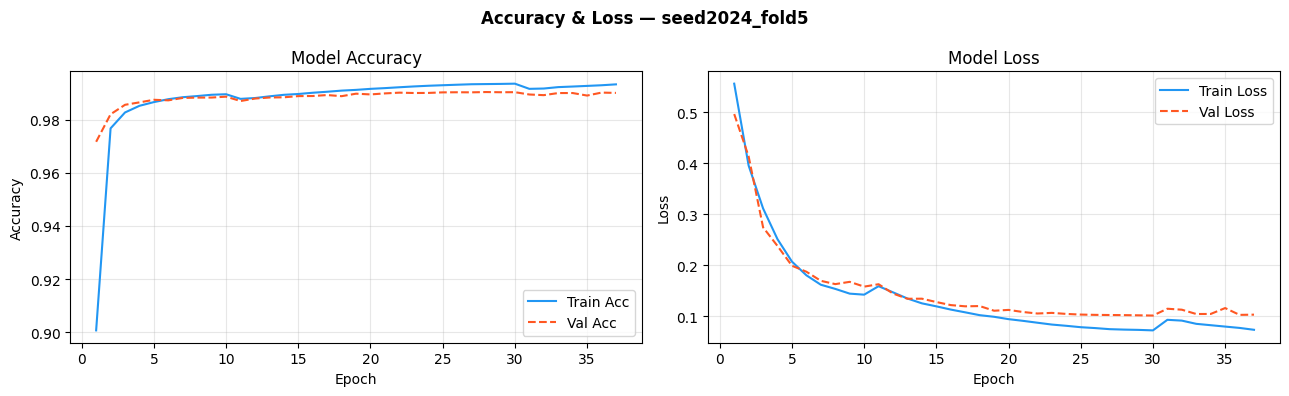

  Saved: curves_acc_loss_seed2024_fold5.png


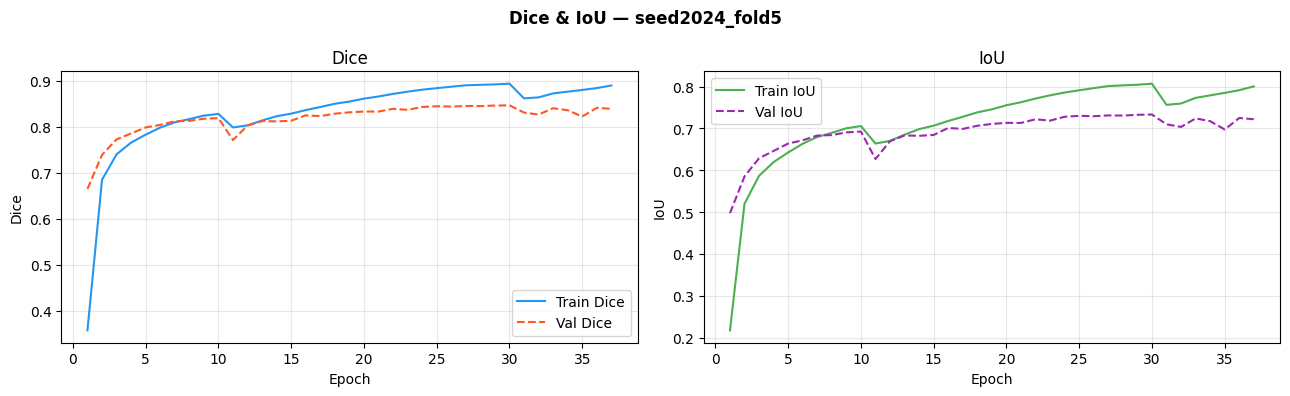

  Saved: curves_dice_iou_seed2024_fold5.png


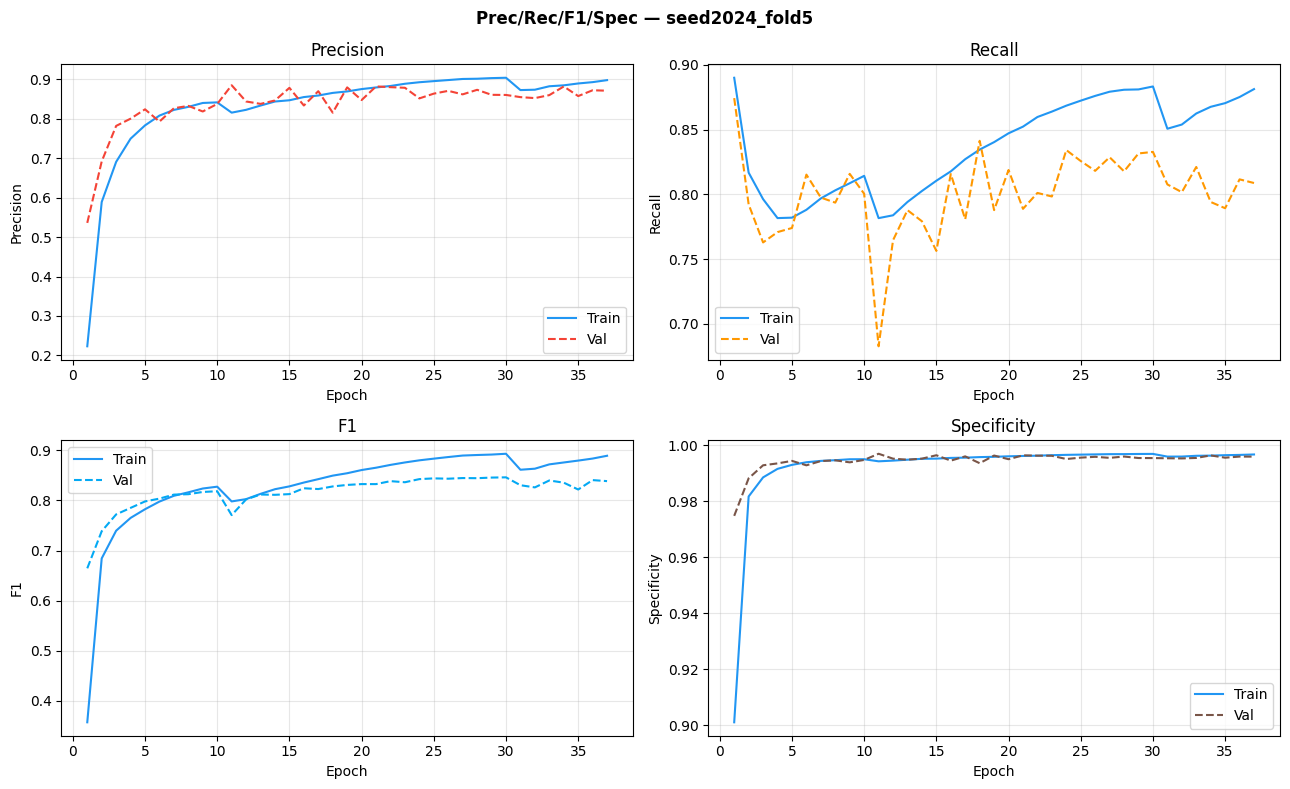

  Saved: curves_prec_rec_f1_spec_seed2024_fold5.png


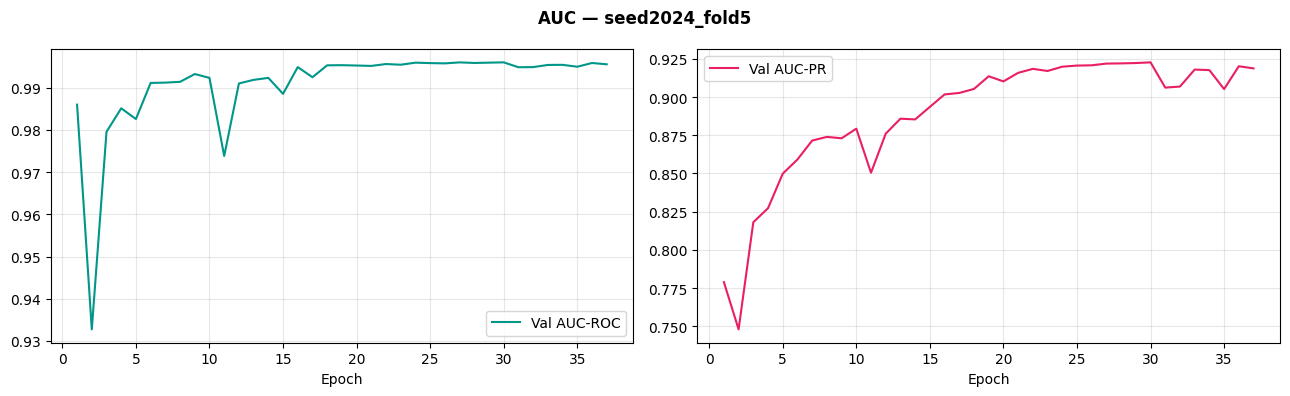

  Saved: curves_auc_seed2024_fold5.png


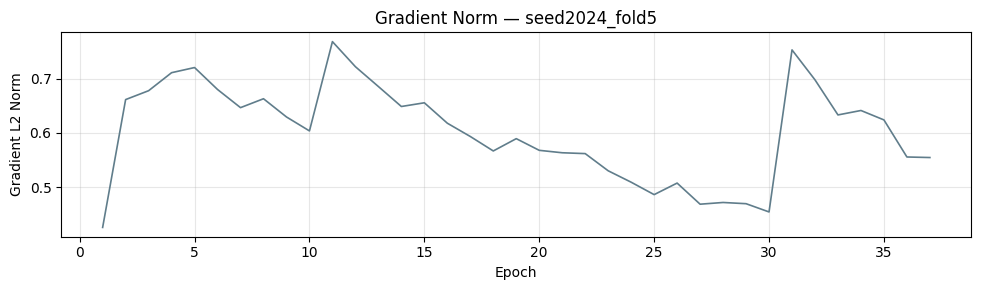

  Saved: curves_grad_norm_seed2024_fold5.png


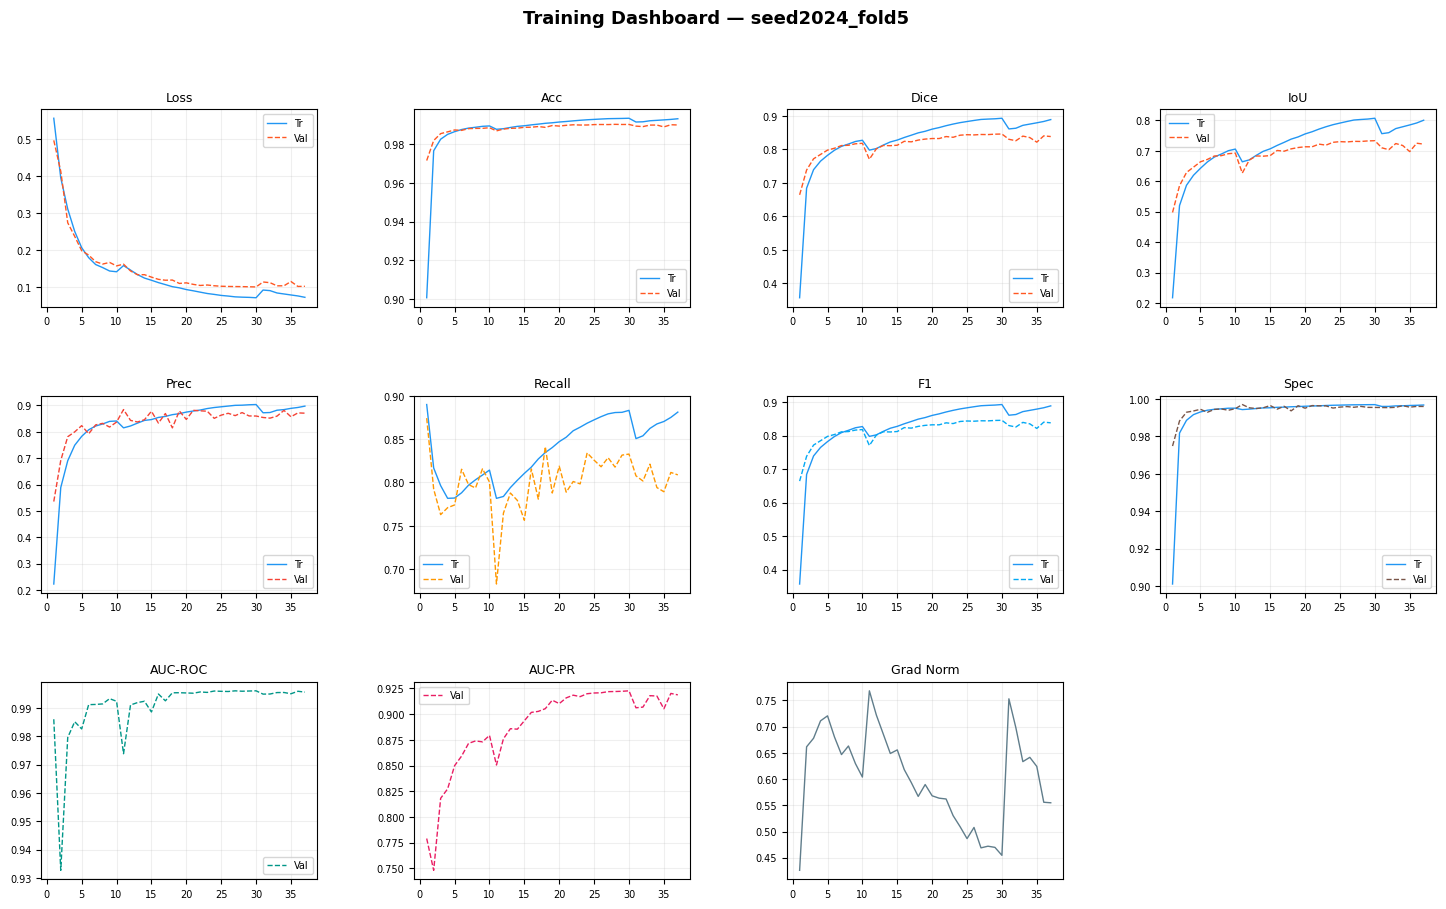

  Saved: dashboard_full_seed2024_fold5.png
  All plots done.


wandb: uploading artifact model-seed2024_fold5; updating run metadata
wandb: uploading artifact model-seed2024_fold5
wandb: uploading history steps 37-37, summary, console lines 18-22
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
wandb:     grad_norm ▁▆▆▇▇▆▆▆▅▅█▇▆▆▆▅▄▄▄▄▄▄▃▃▂▃▂▂▂▂█▇▅▅▅▄▄
wandb:            lr █▇▇▆▄▃▂▂▁████▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁███████▇
wandb: test/accuracy ▁
wandb:   test/auc_pr ▁
wandb:  test/auc_roc ▁
wandb:     test/dice ▁
wandb:       test/f1 ▁
wandb:     test/hd95 ▁
wandb:      test/iou ▁
wandb:           +35 ...
wandb: 
wandb: Run summary:
wandb: best_val_dice 0.84615
wandb:         epoch 37
wandb:     grad_norm 0.55478
wandb:            lr 9e-05
wandb: test/accuracy 0.98955
wandb:   test/auc_pr 0.90938
wandb:  test/auc_roc 0.99543
wandb:     test/dice 0.83185
wandb:       test/f1 0.83185
wandb:     test/hd95 14.78739
wandb:           +36 ...
wandb: 
wandb: 🚀 View run seed2024_fold5 at: https://wandb.ai/tihami246-brac-university/

CSV -> result_seed2024_fold5.csv
PTH -> best_seed2024_fold5.pth

  DONE seed=2024 fold=5
  run_id                              : seed2024_fold5
  dataset                             : dataset2_brats
  seed                                : 2024
  fold                                : 5
  run_time_s                          : 23989.500000
  vram_peak_mb                        : 12377.400000
  train_dice                          : 0.889270
  train_iou                           : 0.800618
  train_accuracy                      : 0.993210
  train_precision                     : 0.897534
  train_recall                        : 0.881157
  train_specificity                   : 0.996788
  train_f1                            : 0.889270
  train_auc_roc                       : 0.996683
  train_auc_pr                        : 0.949794
  train_hd95                          : nan
  train_loss                          : 0.072989
  val_dice                            : 0.838612
  val_iou                

In [10]:
SEED=2024; FOLD=5

full_train_ds=SegDataset(TRAIN_IMG_DIR,TRAIN_MASK_DIR,IMG_SIZE,augment=False)
test_ds      =SegDataset(TEST_IMG_DIR, TEST_MASK_DIR, IMG_SIZE,augment=False)

if len(full_train_ds)>MAX_TRAIN:
    np.random.seed(SEED)
    full_train_ds=Subset(full_train_ds,np.random.choice(len(full_train_ds),MAX_TRAIN,replace=False))
    print(f'Train capped to {MAX_TRAIN}')

if len(test_ds)>MAX_TEST:
    np.random.seed(SEED)
    test_ds=Subset(test_ds,np.random.choice(len(test_ds),MAX_TEST,replace=False))
    print(f'Test capped to {MAX_TEST}')

dummy_labels=np.arange(len(full_train_ds))%3
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
splits=list(skf.split(np.zeros(len(full_train_ds)),dummy_labels))
tr_idx,vl_idx=splits[FOLD-1]
run_id=RUN_ID

print('='*60)
print(f'  dataset2_brats | Seed=2024 | Fold=5')
print(f'  Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(test_ds)}')
print('='*60)

result,history=run_single(tr_idx,vl_idx,test_ds,full_train_ds,SEED,FOLD,run_id)

import shutil
pd.DataFrame([result]).to_csv(f'/kaggle/working/result_seed2024_fold5.csv',index=False)
print(f'CSV -> result_seed2024_fold5.csv')
pth_src=f'{SAVE_DIR}/best_seed2024_fold5.pth'
pth_dst=f'/kaggle/working/best_seed2024_fold5.pth'
if os.path.exists(pth_src): shutil.copy(pth_src,pth_dst); print(f'PTH -> best_seed2024_fold5.pth')
else:
    pths=[f for f in os.listdir(SAVE_DIR) if f.endswith('.pth')]
    if pths: shutil.copy(os.path.join(SAVE_DIR,pths[0]),pth_dst); print('PTH saved (fallback)')
    else: print('WARNING: No .pth!')

print()
print('='*60)
print(f'  DONE seed=2024 fold=5')
print('='*60)
for k,v in result.items():
    if isinstance(v,float): print(f"  {k:<35} : {v:.6f}")
    else: print(f"  {k:<35} : {v}")
df=pd.DataFrame([result])
print(); print('  RAW CSV HEADERS:'); print('  '+','.join(str(c) for c in df.columns))
print('  RAW CSV VALUES:'); print('  '+','.join(str(round(v,6) if isinstance(v,float) else v) for v in df.iloc[0]))


In [11]:
import os,glob
working='/kaggle/working'
print('Output files:')
for fpath in sorted(glob.glob(f'{working}/*.png')+glob.glob(f'{working}/*.csv')+glob.glob(f'{working}/*.pth')):
    print(f'  READY  {os.path.basename(fpath):<50} {os.path.getsize(fpath)/1024/1024:.2f} MB')


Output files:
  READY  best_seed2024_fold5.pth                            126.89 MB
  READY  curves_acc_loss_seed2024_fold5.png                 0.05 MB
  READY  curves_auc_seed2024_fold5.png                      0.05 MB
  READY  curves_dice_iou_seed2024_fold5.png                 0.05 MB
  READY  curves_grad_norm_seed2024_fold5.png                0.03 MB
  READY  curves_prec_rec_f1_spec_seed2024_fold5.png         0.11 MB
  READY  dashboard_full_seed2024_fold5.png                  0.14 MB
  READY  result_seed2024_fold5.csv                          0.00 MB
